# Editing River Hydrographs

In [1]:
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [2]:
maindir = '/results/forcing/rivers/observations/'
origdir = '/data/dlatorne/SOG-projects/SOG-forcing/ECget/'

In [3]:
def missing_dates(data,flowstr):
    full_dates = pd.date_range("2018-01-01", "2022-12-31", freq="D")

    # add all the date
    data['date']=pd.to_datetime(data[['year','month','day']])
    data = data.set_index("date")
    # Collapse duplicate dates before reindexing
    data = (data.groupby("date", as_index=True)[flowstr]
            .mean()
            .to_frame()
            .sort_index()
    )
    data = data.reindex(full_dates)

    # interpolate flow between dates
    data[flowstr] = data[flowstr].interpolate(method="time")

    # rebuilt month day columns
    data = data.rename_axis('date').reset_index()
    data["year"] = data["date"].dt.year
    data["month"] = data["date"].dt.month
    data["day"] = data["date"].dt.day

    return data

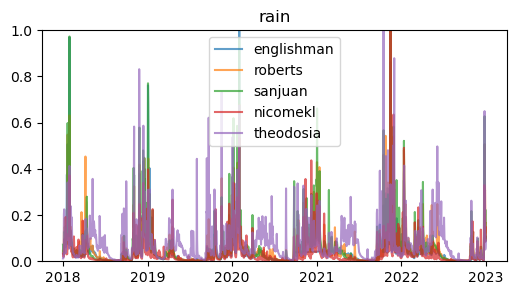

In [4]:
# bring in rivers

########
# RAIN #
########
# start with englishman
rain = pd.read_csv(origdir+'/Englishman_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
rain['date'] = pd.to_datetime(rain[['year','month','day']])
rain = rain[(rain.year>=2018)&(rain.year<=2022)]
rain['englishman'] = rain['flow']
rain.drop(columns=['flow'],inplace=True)
rain = missing_dates(rain,'englishman') # some missing dates

# add others
add = pd.read_csv(maindir+'/RobertsCreek_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
rain['roberts'] = add.flow[(add.year>=2018)&(add.year<=2022)].values

add = pd.read_csv(maindir+'/SanJuan_PortRenfrew_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
add = missing_dates(add,'flow') # some missing dates
rain['sanjuan'] = add.flow.values

add = pd.read_csv(maindir+'/Nicomekl_Langley_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
rain['nicomekl'] = add.flow[(add.year>=2018)&(add.year<=2022)].values

# have to be a bit fancy with how we bring in the theodosia results
# based upon def read_river_Theodosia() in https://github.com/SalishSeaCast/tools/blob/main/I_ForcingFiles/Rivers/MakeDailyRiverNCfiles.ipynb
add = pd.read_csv(maindir+'/Theodosia_Scotty_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
add2 = pd.read_csv(maindir+'/Theodosia_Bypass_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
add3 = pd.read_csv(maindir+'/Theodosia_Diversion_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
theodosia = add.flow[(add.year>=2018)&(add.year<=2022)].values + add3.flow[(add3.year>=2018)&(add3.year<=2022)].values - add2.flow[(add2.year>=2018)&(add2.year<=2022)].values
rain['theodosia'] = theodosia

# normalize river outflows by peak and see if rivers of the same type follow a generally similar curve
fig, ax = plt.subplots(1,1,figsize=[6,3])
ax.plot(rain.date,rain.englishman/np.max(rain.englishman),label=['englishman'],alpha=0.7)
ax.plot(rain.date,rain.roberts/np.max(rain.roberts),label=['roberts'],alpha=0.7)
ax.plot(rain.date,rain.sanjuan/np.max(rain.sanjuan),label=['sanjuan'],alpha=0.7)
ax.plot(rain.date,rain.nicomekl/np.max(rain.nicomekl),label=['nicomekl'],alpha=0.7)
ax.plot(rain.date,rain.theodosia/np.max(rain.theodosia),label=['theodosia'],alpha=0.7)
ax.set_title('rain')
ax.set_ylim([0,1])
ax.legend()

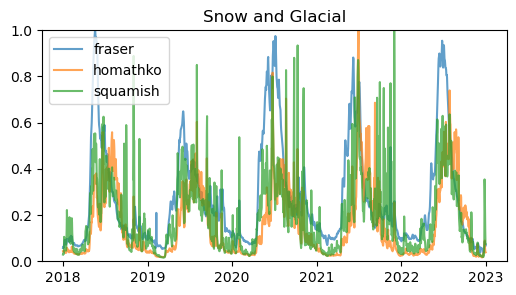

In [5]:
################
# SNOW/GLACIAL #
################
# start with fraser
snow = pd.read_csv(origdir+'/Fraser_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
snow['date'] = pd.to_datetime(snow[['year','month','day']])
snow = snow[(snow.year>=2018)&(snow.year<=2022)]
snow['fraser'] = snow['flow']
snow.drop(columns=['flow'],inplace=True)

# add homathko and squamish
add = pd.read_csv(maindir+'/Homathko_Mouth_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
snow['homathko'] = add.flow[(add.year>=2018)&(add.year<=2022)].values

add = pd.read_csv(maindir+'/Squamish_Brackendale_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
snow['squamish'] = add.flow[(add.year>=2018)&(add.year<=2022)].values

# normalize river outflows by peak and see if rivers of the same type follow a generally similar curve
fig, ax = plt.subplots(1,1,figsize=[6,3])
ax.plot(snow.date,snow.fraser/np.max(snow.fraser),label=['fraser'],alpha=0.7)
ax.plot(snow.date,snow.homathko/np.max(snow.homathko),label=['homathko'],alpha=0.7)
ax.plot(snow.date,snow.squamish/np.max(snow.squamish),label=['squamish'],alpha=0.7)
ax.set_title('Snow and Glacial')
ax.set_ylim([0,1])
ax.legend()

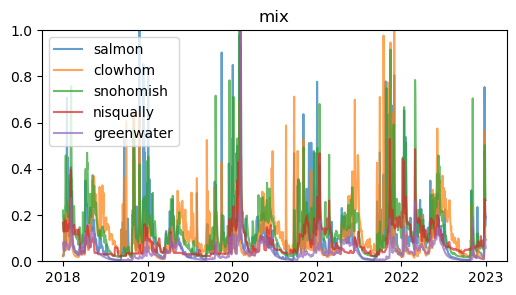

In [6]:
#########
# MIXED #
#########

# start with skagit
mix = pd.read_csv(maindir+'/Skagit_MountVernon_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
mix['date'] = pd.to_datetime(mix[['year','month','day']])
mix = mix[(mix.year>=2018)&(mix.year<=2022)]
mix['skagit'] = mix['flow']
mix.drop(columns=['flow'],inplace=True)
mix = missing_dates(mix,'skagit') # some missing dates

# add others
add = pd.read_csv(maindir+'/Salmon_Sayward_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
add = missing_dates(add,'flow') # some missing dates
mix['salmon'] = add.flow.values

add = pd.read_csv(maindir+'/Clowhom_ClowhomLake_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
mix['clowhom'] = add.flow[(add.year>=2018)&(add.year<=2022)].values

add = pd.read_csv(maindir+'/Snohomish_Monroe_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
add = missing_dates(add,'flow') # some missing dates
mix['snohomish'] = add.flow.values

add = pd.read_csv(maindir+'/Nisqually_McKenna_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
add = missing_dates(add,'flow') # some missing dates
mix['nisqually'] = add.flow.values

add = pd.read_csv(maindir+'/Greenwater_Greenwater_flow',header=None, index_col=False, sep='\s',names=['year', 'month', 'day', 'flow'])
mix['greenwater'] = add.flow[(add.year>=2018)&(add.year<=2022)].values


# normalize river outflows by peak and see if rivers of the same type follow a generally similar curve
fig, ax = plt.subplots(1,1,figsize=[6,3])
ax.plot(mix.date,mix.salmon/np.max(mix.salmon),label=['salmon'],alpha=0.7)
ax.plot(mix.date,mix.clowhom/np.max(mix.clowhom),label=['clowhom'],alpha=0.7)
ax.plot(mix.date,mix.snohomish/np.max(mix.snohomish),label=['snohomish'],alpha=0.7)
ax.plot(mix.date,mix.nisqually/np.max(mix.nisqually),label=['nisqually'],alpha=0.7)
ax.plot(mix.date,mix.greenwater/np.max(mix.greenwater),label=['greenwater'],alpha=0.7)
ax.set_title('mix')
ax.set_ylim([0,1])
ax.legend()

## Snow

In [7]:
# based on the difference between the CMIP4 A1B enssemble mean and the historical snowmelt hydrograph in Elsner2010 (figure 8) this is our monthly scaling of flow:
# felt like a good match to the calculation based on the morrison 2002 paper, less extreme than ficklin 2016
snow_factor = np.array([
    1.7,  # Jan
    1.8,  # Feb
    1.5,  # Mar
    1.3,  # Apr
    1.1,  # May
    0.9,  # Jun
    0.6,  # Jul
    0.7,  # Aug
    0.8,  # Sep
    1.0,  # Oct
    1.3,  # Nov
    1.5   # Dec
])

In [8]:
snow['fraser2100'] = np.nan
snow['homathko2100'] = np.nan
snow['squamish2100'] = np.nan


for m in range(1, 13):
    mask = snow["month"].astype(int) == m
    snow.loc[mask, "fraser2100"] = snow.loc[mask, "fraser"] * snow_factor[m - 1]
    snow.loc[mask, "homathko2100"] = snow.loc[mask, "homathko"] * snow_factor[m - 1]
    snow.loc[mask, "squamish2100"] = snow.loc[mask, "squamish"] * snow_factor[m - 1]

snow

,year,month,day,date,fraser,homathko,squamish,fraser2100,homathko2100,squamish2100
38659,2018,1.0,1.0,2018-01-01,631.6214,72.80000,33.80312,1073.75638,123.760000,57.465304
38660,2018,1.0,2.0,2018-01-02,676.3056,72.80000,36.34236,1149.71952,123.760000,61.782012
38661,2018,1.0,3.0,2018-01-03,620.9424,73.10000,40.70348,1055.60208,124.270000,69.195916
38662,2018,1.0,4.0,2018-01-04,675.9213,75.40000,36.36146,1149.06621,128.180000,61.814482
38663,2018,1.0,5.0,2018-01-05,738.8530,75.80000,47.50382,1256.05010,128.860000,80.756494
...,...,...,...,...,...,...,...,...,...,...
40480,2022,12.0,27.0,2022-12-27,934.9549,152.01740,366.18400,1402.43235,228.026100,549.276000
40481,2022,12.0,28.0,2022-12-28,872.9653,100.27260,239.74650,1309.44795,150.408900,359.619750
40482,2022,12.0,29.0,2022-12-29,787.6319,77.72292,154.16490,1181.44785,116.584380,231.247350
40483,2022,12.0,30.0,2022-12-30,746.9826,69.57014,91.82743,1120.47390,104.355210,137.741145


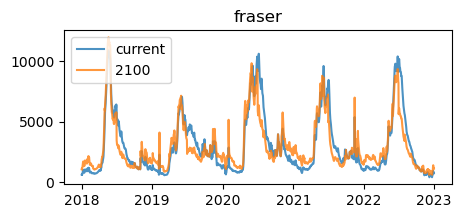

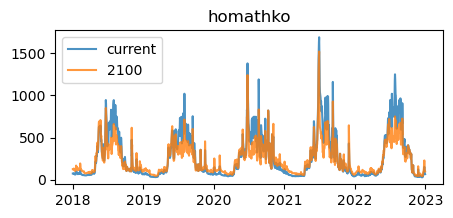

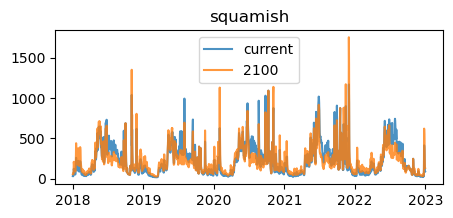

In [9]:
fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(snow.date,snow.fraser,label=['current'],alpha=0.8)
ax.plot(snow.date,snow.fraser2100,label=['2100'],alpha=0.8)
ax.set_title('fraser')
ax.legend()

fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(snow.date,snow.homathko,label=['current'],alpha=0.8)
ax.plot(snow.date,snow.homathko2100,label=['2100'],alpha=0.8)
ax.set_title('homathko')
ax.legend()

fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(snow.date,snow.squamish,label=['current'],alpha=0.8)
ax.plot(snow.date,snow.squamish2100,label=['2100'],alpha=0.8)
ax.set_title('squamish')
ax.legend()

## Rain

In [10]:
# elsner2010, figure 8 (minimal change to rain dominated rivers)
rain_factor = np.array([
    1.1,  # Jan
    1.1,  # Feb
    1.1,  # Mar
    1.0,  # Apr
    1.0,  # May
    1.0,  # Jun
    0.95,  # Jul
    0.9,  # Aug
    0.9,  # Sep
    1.0,  # Oct
    1.0,  # Nov
    1.0   # Dec
])

In [11]:
rain['roberts2100'] = np.nan
rain['sanjuan2100'] = np.nan
rain['nicomekl2100'] = np.nan
rain['theodosia2100'] = np.nan


for m in range(1, 13):
    mask = rain["month"].astype(int) == m
    rain.loc[mask, "roberts2100"] = rain.loc[mask, "roberts"] * rain_factor[m - 1]
    rain.loc[mask, "sanjuan2100"] = rain.loc[mask, "sanjuan"] * rain_factor[m - 1]
    rain.loc[mask, "nicomekl2100"] = rain.loc[mask, "nicomekl"] * rain_factor[m - 1]
    rain.loc[mask, "theodosia2100"] = rain.loc[mask, "theodosia"] * rain_factor[m - 1]

rain

,date,englishman,year,month,day,roberts,sanjuan,nicomekl,theodosia,roberts2100,sanjuan2100,nicomekl2100,theodosia2100
0,2018-01-01,11.30000,2018,1,1,0.796000,58.70000,2.180000,1.149000,0.875600,64.57000,2.398000,1.263900
1,2018-01-02,9.73000,2018,1,2,0.659000,45.30000,1.600000,1.134000,0.724900,49.83000,1.760000,1.247400
2,2018-01-03,8.86000,2018,1,3,0.692000,37.40000,1.380000,1.460000,0.761200,41.14000,1.518000,1.606000
3,2018-01-04,8.41000,2018,1,4,0.744000,32.70000,1.270000,2.160000,0.818400,35.97000,1.397000,2.376000
4,2018-01-05,12.40000,2018,1,5,2.120000,54.30000,3.080000,19.240000,2.332000,59.73000,3.388000,21.164000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1821,2022-12-27,101.73440,2022,12,27,8.802188,319.20140,19.546340,17.243434,8.802188,319.20140,19.546340,17.243434
1822,2022-12-28,57.46979,2022,12,28,4.648715,155.84830,21.059930,10.298934,4.648715,155.84830,21.059930,10.298934
1823,2022-12-29,31.18368,2022,12,29,2.107743,80.49861,5.768711,4.809303,2.107743,80.49861,5.768711,4.809303
1824,2022-12-30,25.66979,2022,12,30,2.784931,107.65170,6.720871,5.779444,2.784931,107.65170,6.720871,5.779444


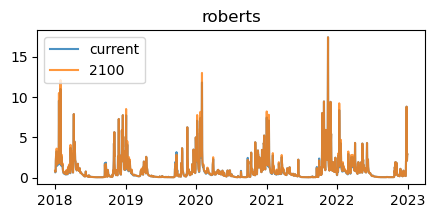

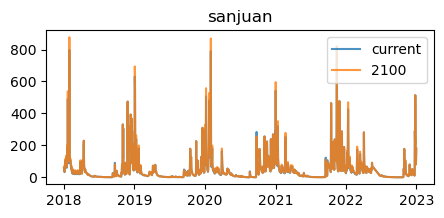

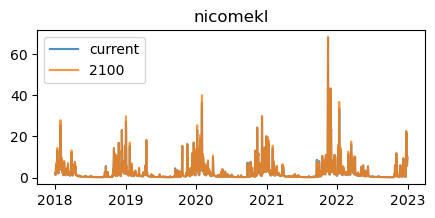

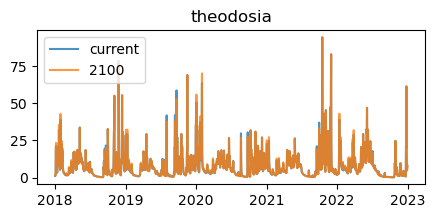

In [12]:
fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(rain.date,rain.roberts,label=['current'],alpha=0.8)
ax.plot(rain.date,rain.roberts2100,label=['2100'],alpha=0.8)
ax.set_title('roberts')
ax.legend()

fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(rain.date,rain.sanjuan,label=['current'],alpha=0.8)
ax.plot(rain.date,rain.sanjuan2100,label=['2100'],alpha=0.8)
ax.set_title('sanjuan')
ax.legend()

fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(rain.date,rain.nicomekl,label=['current'],alpha=0.8)
ax.plot(rain.date,rain.nicomekl2100,label=['2100'],alpha=0.8)
ax.set_title('nicomekl')
ax.legend()

fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(rain.date,rain.theodosia,label=['current'],alpha=0.8)
ax.plot(rain.date,rain.theodosia2100,label=['2100'],alpha=0.8)
ax.set_title('theodosia')
ax.legend()

## Mixed

In [13]:
# elsner2010, figure 8 (significant shift)
mix_factor = np.array([
    2.1,  # Jan
    2.1,  # Feb
    1.6,  # Mar
    1.1,  # Apr
    0.7,  # May
    0.4,  # Jun
    0.3,  # Jul
    0.5,  # Aug
    0.6,  # Sep
    0.8,  # Oct
    1.2,  # Nov
    1.6   # Dec
])

In [14]:
mix['salmon2100'] = np.nan
mix['clowhom2100'] = np.nan
mix['snohomish2100'] = np.nan
mix['nisqually2100'] = np.nan
mix['greenwater2100'] = np.nan


for m in range(1, 13):
    mask = mix["month"].astype(int) == m
    mix.loc[mask, "salmon2100"] = mix.loc[mask, "salmon"] * mix_factor[m - 1]
    mix.loc[mask, "clowhom2100"] = mix.loc[mask, "clowhom"] * mix_factor[m - 1]
    mix.loc[mask, "snohomish2100"] = mix.loc[mask, "snohomish"] * mix_factor[m - 1]
    mix.loc[mask, "nisqually2100"] = mix.loc[mask, "nisqually"] * mix_factor[m - 1]
    mix.loc[mask, "greenwater2100"] = mix.loc[mask, "greenwater"] * mix_factor[m - 1]

mix

,date,skagit,year,month,day,salmon,clowhom,snohomish,nisqually,greenwater,salmon2100,clowhom2100,snohomish2100,nisqually2100,greenwater2100
0,2018-01-01,478.5539,2018,1,1,15.50000,2.88000,430.4154,83.81773,12.487710,32.550000,6.048000,903.87234,176.017233,26.224191
1,2018-01-02,478.5539,2018,1,2,15.00000,2.79000,342.6333,74.47318,10.222360,31.500000,5.859000,719.52993,156.393678,21.466956
2,2018-01-03,464.3955,2018,1,3,15.30000,3.01000,291.6630,68.80982,8.806525,32.130000,6.321000,612.49230,144.500622,18.493703
3,2018-01-04,450.2371,2018,1,4,16.80000,3.42000,259.0987,64.84547,7.843754,35.280000,7.182000,544.10727,136.175487,16.471883
4,2018-01-05,427.5837,2018,1,5,26.60000,16.70000,253.4354,64.84547,7.475635,55.860000,35.070000,532.21434,136.175487,15.698833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1821,2022-12-27,1480.9690,2022,12,27,286.91320,42.57222,985.4246,135.92060,17.273250,459.061120,68.115552,1576.67936,217.472960,27.637200
1822,2022-12-28,1265.7610,2022,12,28,153.74650,24.97569,982.5930,129.97410,16.763550,245.994400,39.961104,1572.14880,207.958560,26.821680
1823,2022-12-29,852.3357,2022,12,29,96.06042,14.40451,679.6032,105.33850,12.232860,153.696672,23.047216,1087.36512,168.541600,19.572576
1824,2022-12-30,696.5933,2022,12,30,117.24030,12.32396,523.8608,99.95830,10.165730,187.584480,19.718336,838.17728,159.933280,16.265168


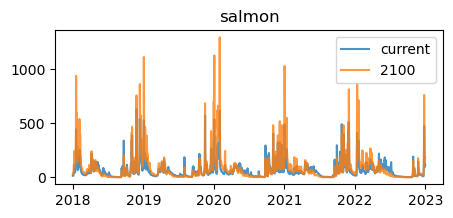

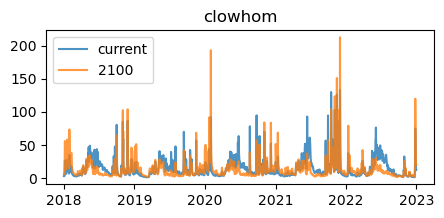

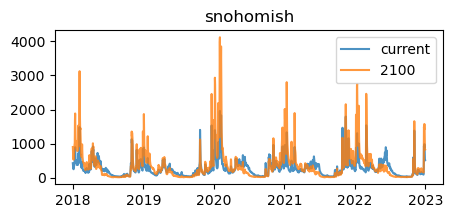

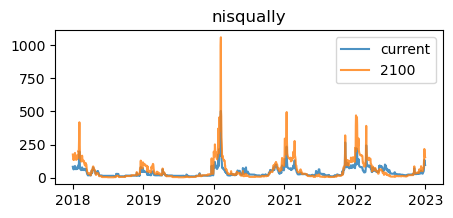

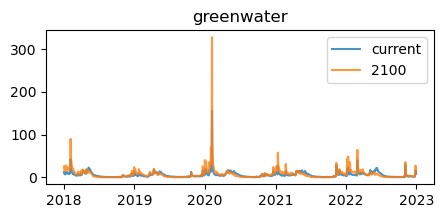

In [15]:
fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(mix.date,mix.salmon,label=['current'],alpha=0.8)
ax.plot(mix.date,mix.salmon2100,label=['2100'],alpha=0.8)
ax.set_title('salmon')
ax.legend()

fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(mix.date,mix.clowhom,label=['current'],alpha=0.8)
ax.plot(mix.date,mix.clowhom2100,label=['2100'],alpha=0.8)
ax.set_title('clowhom')
ax.legend()

fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(mix.date,mix.snohomish,label=['current'],alpha=0.8)
ax.plot(mix.date,mix.snohomish2100,label=['2100'],alpha=0.8)
ax.set_title('snohomish')
ax.legend()

fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(mix.date,mix.nisqually,label=['current'],alpha=0.8)
ax.plot(mix.date,mix.nisqually2100,label=['2100'],alpha=0.8)
ax.set_title('nisqually')
ax.legend()

fig, ax = plt.subplots(1,1,figsize=[5,2])
ax.plot(mix.date,mix.greenwater,label=['current'],alpha=0.8)
ax.plot(mix.date,mix.greenwater2100,label=['2100'],alpha=0.8)
ax.set_title('greenwater')
ax.legend()